# Encontro 6 - Análise Exploratória de Dados (EDA)

**Aluno - prática guiada**

> **Ideia central:** EDA é uma investigação orientada por perguntas. Cada resultado deve virar uma afirmação sustentada por evidência e acompanhada por uma limitação.

Usaremos a base **Automobile** preparada no encontro anterior. Cada linha representa um automóvel e `price` é a variável central desta investigação.

**Ao final, você deverá conseguir:**

1. organizar uma EDA em análises univariadas, bivariadas e multivariadas;
2. resumir variáveis numéricas e categóricas sem confundir comando com interpretação;
3. escolher histogramas, boxplots, barras, dispersão e heatmap conforme a pergunta;
4. comparar grupos com `groupby()`;
5. interpretar direção, força e limites de uma correlação;
6. introduzir Pearson, valor de p e qui-quadrado sem transformar significância em causalidade;
7. registrar insights no formato **afirmação - evidência - interpretação - limitação**.

## Como usar

Execute as células na ordem com **Shift + Enter**. O notebook procura `dados/automoveis_preparados.csv` e depois `automoveis_preparados.csv`. Se nenhum arquivo local estiver disponível, reconstrói a preparação do Encontro 5 a partir da fonte pública da UCI.

As caixas **Pare e interprete** pedem uma leitura antes de executar o próximo comando. Um gráfico não é a conclusão; ele é uma forma de evidência.

## 1. Ambiente e carregamento da base preparada

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
AZUL = "#3D8DFF"
CINZA = "#5F6B7A"

In [4]:
COLUNAS_BRUTAS = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

def preparar_fallback(df):
    # Reproduz as decisões didáticas essenciais do Encontro 5.
    df = df.dropna(subset=["price"]).copy()
    for coluna in ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]:
        df[coluna] = df[coluna].fillna(df[coluna].median())
    df["num-of-doors"] = df["num-of-doors"].fillna(df["num-of-doors"].mode()[0])
    df["city-L/100km"] = 235 / df["city-mpg"]
    df["length_minmax"] = (
        (df["length"] - df["length"].min())
        / (df["length"].max() - df["length"].min())
    )
    df["length_zscore"] = (df["length"] - df["length"].mean()) / df["length"].std()
    df["faixa_preco"] = pd.cut(
        df["price"], [0, 10_000, 20_000, float("inf")],
        labels=["baixo", "medio", "alto"], include_lowest=True,
    )
    dummies = pd.get_dummies(df["fuel-type"], prefix="fuel", dtype=int)
    return pd.concat([df, dummies], axis=1)

candidatos = [Path("dados/automoveis_preparados.csv"), Path("automoveis_preparados.csv")]
caminho = next((p for p in candidatos if p.exists()), None)

if caminho is not None:
    df = pd.read_csv(caminho)
    origem = str(caminho)
else:
    origem = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
    df_bruto = pd.read_csv(origem, names=COLUNAS_BRUTAS, na_values="?")
    df = preparar_fallback(df_bruto)

if "fuel-type" not in df.columns:
    df["fuel-type"] = np.where(df["fuel_diesel"].eq(1), "diesel", "gas")

assert len(df) == 201
assert int(df.isna().sum().sum()) == 0
print("Origem:", origem)
print("Dimensões:", df.shape)
df.head(3)

Origem: https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data
Dimensões: (201, 32)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,length_minmax,length_zscore,faixa_preco,fuel_diesel,fuel_gas
0,3,115.00,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,"13,495.00",11.19,0.41,-0.44,medio,0,1
1,3,115.00,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,"16,500.00",11.19,0.41,-0.44,medio,0,1
2,1,115.00,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154.00,"5,000.00",19,26,"16,500.00",12.37,0.45,-0.24,medio,0,1


## 2. Comece pela pergunta, não pelo gráfico

| Nível | Pergunta exemplo | Evidência possível |
|---|---|---|
| **Univariada** | Como `price` está distribuído? | `describe()`, histograma, boxplot |
| **Bivariada** | `horsepower` está relacionada a `price`? | dispersão, Pearson, `groupby()` |
| **Multivariada** | A relação potência-preço muda com o combustível? | dispersão com `hue`, agrupamentos múltiplos |

Uma boa EDA alterna quatro movimentos: **perguntar, calcular, visualizar e interpretar**.

## 3. Análise univariada: centro, dispersão e forma

In [5]:
resumo_preco = df["price"].describe().rename("price")
resumo_preco

,price
count,201.00
mean,"13,207.13"
std,"7,947.07"
min,"5,118.00"
25%,"7,775.00"
50%,"10,295.00"
75%,"16,500.00"
max,"45,400.00"


In [6]:
media = df["price"].mean()
mediana = df["price"].median()
assimetria = df["price"].skew()

print(f"Média: US$ {media:,.2f}")
print(f"Mediana: US$ {mediana:,.2f}")
print(f"Assimetria: {assimetria:.2f}")

Média: US$ 13,207.13
Mediana: US$ 10,295.00
Assimetria: 1.81


<div style="border-left: 4px solid #3D8DFF; padding: 8px 12px; background: #F6F9FF">
<strong>Pare e interprete:</strong> se a média é bem maior que a mediana, que tipo de forma você espera ver no histograma?
</div>

Em distribuições assimétricas, média e mediana respondem perguntas diferentes. A média usa toda a magnitude dos valores; a mediana localiza a observação central e é menos sensível a extremos.

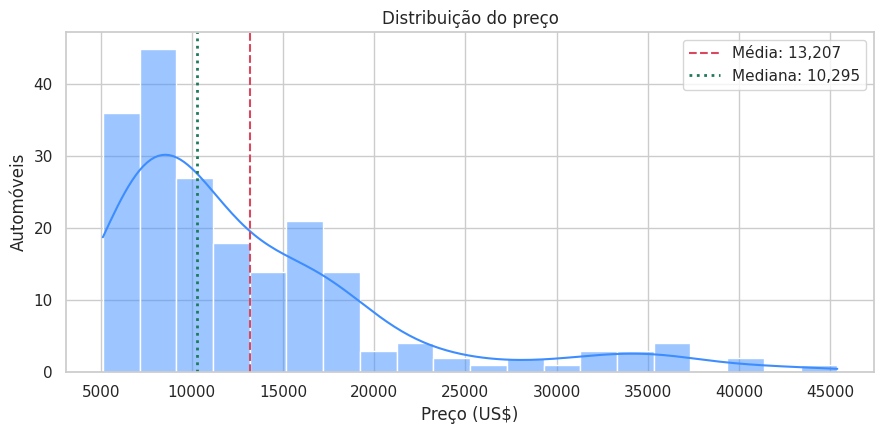

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=df, x="price", bins=20, kde=True, color=AZUL, ax=ax)
ax.axvline(media, color="#D9485F", linestyle="--", label=f"Média: {media:,.0f}")
ax.axvline(mediana, color="#1F7A5A", linestyle=":", linewidth=2, label=f"Mediana: {mediana:,.0f}")
ax.set(title="Distribuição do preço", xlabel="Preço (US$)", ylabel="Automóveis")
ax.legend()
plt.tight_layout()
plt.show()

## Como funciona a plotagem de gráficos no Matplotlib

No Matplotlib, uma forma comum de criar gráficos é utilizando **Figura (`fig`)** e **Eixos (`ax`)**.

```python
import matplotlib.pyplot as plt

# 1. Cria a figura e a área onde o gráfico será desenhado
fig, ax = plt.subplots(figsize=(9, 4.5))

# 2. Desenha os dados no eixo
ax.plot(x, y)

# 3. Configura título e nomes dos eixos
ax.set(
    title="Título do gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y"
)

# 4. Ajusta automaticamente as margens
plt.tight_layout()

# 5. Exibe o gráfico
plt.show()
```

### `fig` e `ax`

```python
fig, ax = plt.subplots()
```

O `plt.subplots()` retorna dois objetos:

- **`fig`**: representa a figura inteira, ou seja, o espaço que contém o gráfico.
- **`ax`**: representa a área de plotagem, onde os dados são efetivamente desenhados.

Podemos pensar assim:

```text
fig
┌────────────────────────────────────┐
│                                    │
│       ax                           │
│   ┌────────────────────────────┐   │
│   │                            │   │
│   │          GRÁFICO           │   │
│   │                            │   │
│   └────────────────────────────┘   │
│                                    │
└────────────────────────────────────┘
```

### Plotando dados

Depois de criar o `ax`, utilizamos seus métodos para adicionar elementos ao gráfico:

```python
ax.plot(x, y)          # gráfico de linha
ax.scatter(x, y)       # gráfico de dispersão
ax.bar(x, y)           # gráfico de barras
ax.axvline(valor)      # linha vertical
ax.axhline(valor)      # linha horizontal
```

Também podemos utilizar bibliotecas como o **Seaborn** e indicar em qual `ax` o gráfico deverá ser desenhado:

```python
sns.histplot(data=df, x="price", ax=ax)
```

### Configurando o gráfico

O objeto `ax` também é utilizado para modificar o gráfico:

```python
ax.set(
    title="Distribuição dos preços",
    xlabel="Preço",
    ylabel="Quantidade"
)

ax.legend()
```

### Fluxo geral

A lógica básica costuma ser:

**criar a figura → desenhar no `ax` → configurar o `ax` → exibir**

```text
fig, ax = plt.subplots()
          ↓
     ax.plot(...)
          ↓
      ax.set(...)
          ↓
     plt.show()
```

### 3.1 Boxplot e possíveis outliers

In [8]:
q1, q3 = df["price"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
possiveis_outliers = df.loc[~df["price"].between(limite_inferior, limite_superior)]

print(f"Q1: {q1:,.0f} | Q3: {q3:,.0f} | IQR: {iqr:,.0f}")
print(f"Limite inferior pelo critério 1,5 x IQR: {limite_inferior:_.0f}")
print(f"Limite superior pelo critério 1,5 x IQR: {limite_superior:,.0f}")
print("Pontos sinalizados:", len(possiveis_outliers))

Q1: 7,775 | Q3: 16,500 | IQR: 8,725
Limite inferior pelo critério 1,5 x IQR: -5_312
Limite superior pelo critério 1,5 x IQR: 29,588
Pontos sinalizados: 14


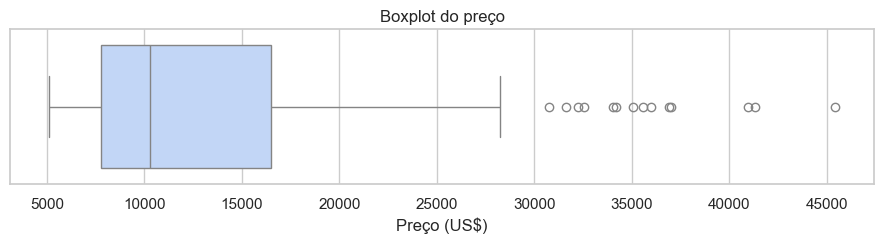

In [ ]:
fig, ax = plt.subplots(figsize=(9, 2.6))
sns.boxplot(data=df, x="price", color="#B9D4FF", ax=ax)
ax.set(title="Boxplot do preço", xlabel="Preço (US$)")
plt.tight_layout()
plt.show()

> **Outlier é um sinal para investigar, não uma ordem para excluir.** Um ponto distante pode ser erro, caso raro legítimo, fraude ou justamente a observação mais informativa. O critério do boxplot descreve distância; não conhece o contexto.

### 3.2 Categorias: contagem e proporção

In [ ]:
frequencia_carroceria = pd.DataFrame({
    "n": df["body-style"].value_counts(),
    "proporcao_%": df["body-style"].value_counts(normalize=True).mul(100).round(1),
})
frequencia_carroceria

,n,proporcao_%
body-style,,
sedan,94,46.80
hatchback,68,33.80
wagon,25,12.40
hardtop,8,4.00
convertible,6,3.00


## 4. `groupby()`: compare uma medida entre grupos

In [ ]:
preco_por_carroceria = (
    df.groupby("body-style", observed=True)["price"]
      .agg(n="count", media="mean", mediana="median", desvio_padrao="std")
      .sort_values("media", ascending=False)
)
preco_por_carroceria

,n,media,mediana,desvio_padrao
body-style,,,,
hardtop,8,"22,208.50","19,687.50","14,555.52"
convertible,6,"21,890.50","17,084.50","11,187.80"
sedan,94,"14,459.76","11,078.50","8,523.21"
wagon,25,"12,371.96","11,694.00","5,120.95"
hatchback,68,"9,957.44","8,672.00","4,148.86"


## `groupby()` e agregação no Pandas

O `groupby()` é usado para **agrupar os dados por uma categoria** e calcular estatísticas para cada grupo.

```python
preco_por_carroceria = (
    df.groupby("body-style", observed=True)["price"]
      .agg(
          n="count",
          media="mean",
          mediana="median",
          desvio_padrao="std"
      )
      .sort_values("media", ascending=False)
)
```

### Como interpretar

```python
df.groupby("body-style")
```

Agrupa os automóveis pelo tipo de carroceria.

```python
["price"]
```

Seleciona a variável `price` para ser analisada dentro de cada grupo.

```python
.agg(...)
```

Calcula várias estatísticas ao mesmo tempo:

- `count` → quantidade de automóveis;
- `mean` → preço médio;
- `median` → mediana dos preços;
- `std` → desvio padrão dos preços.

```python
.sort_values("media", ascending=False)
```

Ordena o resultado pela média do preço, do **maior para o menor**.

### Fluxo geral

```text
DataFrame
   ↓
agrupar por body-style
   ↓
selecionar price
   ↓
calcular estatísticas
   ↓
ordenar pela média
```

Esse é um exemplo de **análise bivariada**, pois relaciona:

```text
body-style  ↔  price
categórica     numérica
```

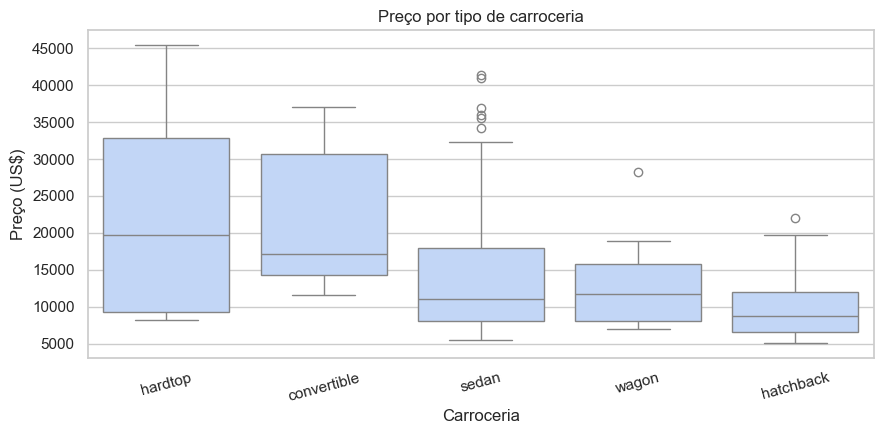

In [ ]:
ordem = preco_por_carroceria.index
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="body-style", y="price", order=ordem, color="#B9D4FF", ax=ax)
ax.set(title="Preço por tipo de carroceria", xlabel="Carroceria", ylabel="Preço (US$)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div style="border-left: 4px solid #3D8DFF; padding: 8px 12px; background: #F6F9FF">
<strong>Pare e interprete:</strong> o grupo de maior média também possui muitos casos? Compare média, mediana, dispersão e <code>n</code> antes de afirmar que uma categoria “é mais cara”.
</div>

## 5. Relações numéricas: dispersão e correlação

In [ ]:
variaveis_numericas = [
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-size", "bore", "stroke", "compression-ratio",
    "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

corr = df[variaveis_numericas].corr(numeric_only=True)
correlacoes_preco = (
    corr["price"].drop("price")
        .sort_values(key=lambda serie: serie.abs(), ascending=False)
)
correlacoes_preco.to_frame("r_com_price")

,r_com_price
engine-size,0.87
curb-weight,0.83
horsepower,0.81
width,0.75
highway-mpg,-0.70
length,0.69
city-mpg,-0.69
wheel-base,0.58
bore,0.54
height,0.14


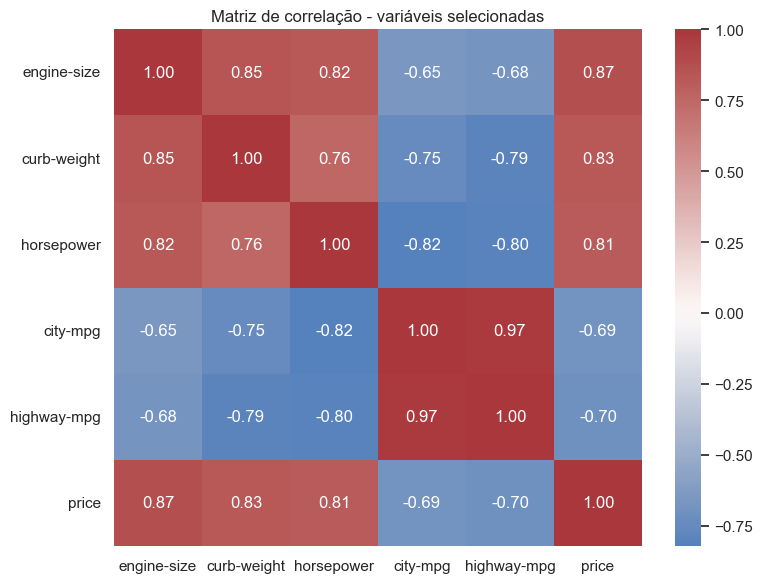

In [ ]:
foco = ["engine-size", "curb-weight", "horsepower", "city-mpg", "highway-mpg", "price"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[foco].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Matriz de correlação - variáveis selecionadas")
plt.tight_layout()
plt.show()

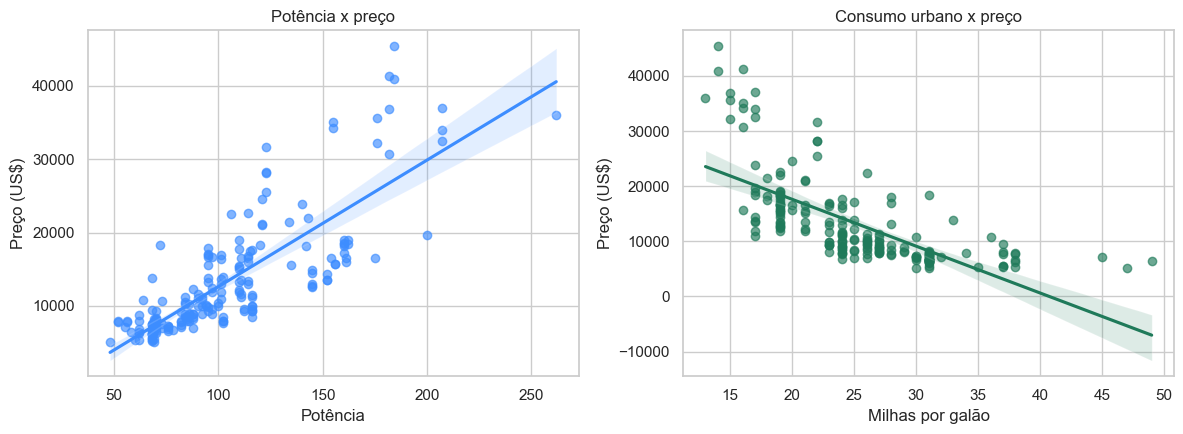

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=df, x="horsepower", y="price", scatter_kws={"alpha": 0.65}, color=AZUL, ax=axes[0])
axes[0].set(title="Potência x preço", xlabel="Potência", ylabel="Preço (US$)")
sns.regplot(data=df, x="city-mpg", y="price", scatter_kws={"alpha": 0.65}, color="#1F7A5A", ax=axes[1])
axes[1].set(title="Consumo urbano x preço", xlabel="Milhas por galão", ylabel="Preço (US$)")
plt.tight_layout()
plt.show()

Correlação de Pearson varia de `-1` a `+1` e resume **direção e força de uma relação linear**. Valores próximos de zero não eliminam relações curvas ou dependências por subgrupos.

> **Correlação não implica causalidade.**

### 5.1 Pearson e valor de p: uma introdução

In [ ]:
resultado_pearson = stats.pearsonr(df["horsepower"], df["price"])
print(f"r de Pearson: {resultado_pearson.statistic:.3f}")
print(f"valor de p: {resultado_pearson.pvalue:.3e}")

r de Pearson: 0.811
valor de p: 4.122e-48


### Correlação de Pearson e p-value

O **coeficiente de Pearson (`r`)** mede a **força e a direção da correlação linear** entre duas variáveis.

- `r > 0`: correlação positiva
- `r < 0`: correlação negativa
- `r ≈ 0`: pouca ou nenhuma correlação linear

O **p-value** indica se há evidência estatística de que a correlação é diferente de zero.

- `p < 0,05`: correlação estatisticamente significativa
- `p ≥ 0,05`: não há evidência suficiente para afirmar que existe correlação linear

> **Resumo:** `r` indica a força e a direção da correlação; `p-value` indica sua significância estatística.



## 6. Categórica x categórica: tabela de contingência e qui-quadrado

In [ ]:
tabela_contingencia = pd.crosstab(df["fuel-type"], df["body-style"])
tabela_contingencia

body-style,convertible,hardtop,hatchback,sedan,wagon
fuel-type,,,,,
diesel,0,1,1,15,3
gas,6,7,67,79,22


In [ ]:
chi2, p_value_chi2, graus_liberdade, esperadas = stats.chi2_contingency(tabela_contingencia)
esperadas_df = pd.DataFrame(
    esperadas, index=tabela_contingencia.index, columns=tabela_contingencia.columns
)

print(f"Qui-quadrado: {chi2:.3f}")
print(f"Graus de liberdade: {graus_liberdade}")
print(f"Valor de p: {p_value_chi2:.4f}")
print(f"Menor frequência esperada: {esperadas_df.min().min():.2f}")

Qui-quadrado: 10.081
Graus de liberdade: 4
Valor de p: 0.0391
Menor frequência esperada: 0.60


### Teste Qui-Quadrado de Independência

O **teste qui-quadrado de independência** é utilizado para verificar se existe **associação entre duas variáveis categóricas**.

Neste exemplo, analisamos:

- `fuel-type`: tipo de combustível
- `body-style`: tipo de carroceria

O teste compara as **frequências observadas** no dataset com as **frequências esperadas** caso as duas variáveis fossem independentes.

As hipóteses são:

- **H₀:** as variáveis são independentes, ou seja, não há associação entre elas.
- **H₁:** existe associação entre as variáveis.

### Valor de qui-quadrado (`chi2`)

O valor de **qui-quadrado** mede o quanto as frequências observadas diferem das frequências esperadas.

- Valor pequeno: observado e esperado são parecidos.
- Valor maior: há uma diferença maior entre observado e esperado.

Porém, o `chi2` **não deve ser interpretado sozinho**, pois sua magnitude depende também do tamanho da tabela e dos graus de liberdade. Para decidir se a associação é estatisticamente significativa, usamos principalmente o **p-value**.

### Graus de liberdade

Os **graus de liberdade** dependem da quantidade de categorias das duas variáveis:

`gl = (nº de linhas - 1) × (nº de colunas - 1)`

Eles são usados, junto com o valor de `chi2`, para calcular o p-value.

Em geral, não interpretamos os graus de liberdade como "fortes" ou "fracos"; eles descrevem a estrutura da tabela analisada.

### Frequências esperadas

As **frequências esperadas** representam quantos casos esperaríamos em cada combinação de categorias caso as duas variáveis fossem independentes.

O teste compara:

`frequência observada × frequência esperada`

Quanto maiores forem as diferenças entre elas, maior tende a ser o valor de qui-quadrado.

Também é importante verificar se as frequências esperadas são muito pequenas. Uma regra prática comum é que elas sejam, em geral, próximas ou superiores a **5**.

Por isso, o código verifica a **menor frequência esperada**:

- mínimo ≥ 5: situação geralmente mais adequada para o teste;
- mínimo < 5: indica que pelo menos uma célula possui frequência esperada baixa e o resultado deve ser interpretado com mais cuidado.

### p-value

O **p-value** indica se há evidência estatística de associação entre as variáveis.

- `p < 0,05`: rejeitamos H₀ e consideramos que há evidência de associação.
- `p ≥ 0,05`: não há evidência suficiente para afirmar que existe associação.

> **Resumo:** o `chi2` mede a diferença entre observado e esperado, os graus de liberdade representam a estrutura da tabela, as frequências esperadas mostram o que seria esperado caso não houvesse associação, e o `p-value` indica se a associação encontrada é estatisticamente significativa.

## 7. Análise multivariada: acrescente contexto à relação

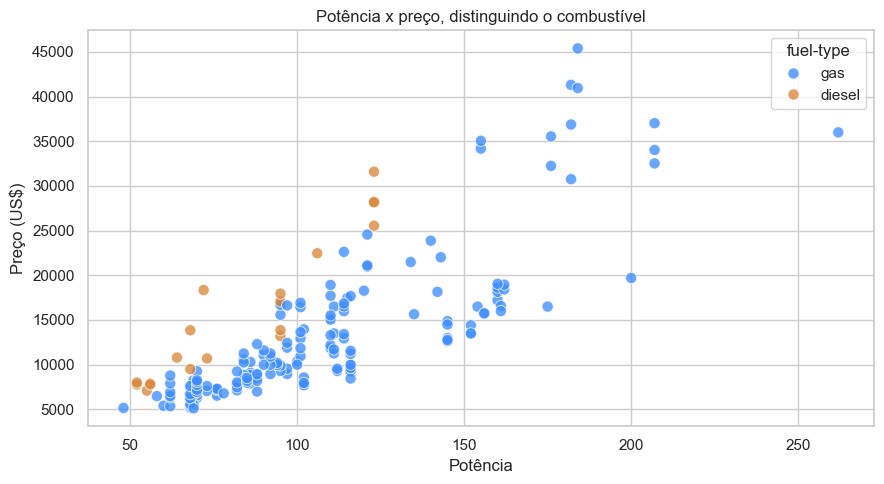

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=df, x="horsepower", y="price", hue="fuel-type",
    palette={"gas": AZUL, "diesel": "#D9873C"}, alpha=0.78, s=65, ax=ax,
)
ax.set(title="Potência x preço, distinguindo o combustível", xlabel="Potência", ylabel="Preço (US$)")
plt.tight_layout()
plt.show()

Adicionar uma terceira variável pode revelar composição de grupos, mas também aumenta a carga visual. Use cor, tamanho e estilo com parcimônia. Uma visualização multivariada só é melhor quando responde uma pergunta mais específica.

## 8. Laboratório - investigue e argumente

Responda às sete perguntas. Não entregue apenas saídas: para cada conclusão, registre **afirmação, evidência, interpretação e limitação**.

1. Como o preço está distribuído?
2. Quantos pontos são sinalizados como possíveis outliers pelo critério de 1,5 x IQR?
3. Qual tipo de carroceria tem maior preço médio? O tamanho do grupo sustenta uma afirmação forte?
4. Potência e preço parecem relacionados? Em que direção e com que intensidade?
5. Qual variável numérica possui maior correlação absoluta com `price` entre as variáveis originais selecionadas?
6. Crie um gráfico que sustente uma conclusão e escreva uma legenda interpretativa.
7. Escreva duas conclusões e ao menos uma limitação geral da análise.

### 1 e 2 - Distribuição e possíveis outliers

In [ ]:
# TODO: calcule média, mediana, assimetria, Q1, Q3, IQR e limites.
# Depois conte os pontos sinalizados e crie histograma + boxplot.
resposta_distribuicao = None

### 3 - Preço por carroceria

In [ ]:
# TODO: use groupby() e agregue n, média, mediana e desvio-padrão.
# Ordene pela média e compare a estabilidade dos grupos.
resposta_grupos = None

### 4 - Potência e preço

In [ ]:
# TODO: crie um scatterplot e calcule Pearson para horsepower x price.
resultado_potencia = None

### 5 - Maior correlação absoluta com preço

In [ ]:
# TODO: use apenas as variáveis originais listadas em variaveis_numericas.
# Remova a autocorrelação de price e ordene pelo valor absoluto.
resposta_correlacoes = None

### 6 - Seu gráfico-evidência

In [ ]:
# TODO: crie um gráfico coerente com uma pergunta específica.
# Dê ao título a forma de uma conclusão provisória.

### 7. Insights e limitações

**Insight 1:** substitua por uma afirmação verificável.  
**Evidência:** informe número, tabela ou padrão visual.  
**Interpretação:** explique o que o resultado pode significar.  
**Limitação:** registre o que não pode ser concluído.

**Insight 2:** substitua por uma afirmação verificável.  
**Evidência:** informe número, tabela ou padrão visual.  
**Interpretação:** explique o que o resultado pode significar.  
**Limitação:** registre o que não pode ser concluído.

In [ ]:
# TODO: organize um DataFrame-resumo e exporte suas evidências.
# resumo_eda.to_csv("resumo_eda_entrega.csv", index=False)
# resposta_grupos.to_csv("preco_por_carroceria_entrega.csv")
# resposta_correlacoes.to_csv("correlacoes_preco_entrega.csv")

## Checklist da entrega

- [ ] formulei perguntas antes de escolher gráficos;
- [ ] descrevi a distribuição de `price` com números e visualização;
- [ ] tratei pontos extremos como sinais para investigação;
- [ ] comparei grupos mostrando também o tamanho `n`;
- [ ] interpretei sinal e intensidade da correlação;
- [ ] não converti correlação ou valor de p em causalidade;
- [ ] usei ao menos um gráfico como evidência de uma conclusão;
- [ ] escrevi duas conclusões e ao menos uma limitação;
- [ ] o notebook executa do início ao fim;
- [ ] exportei os resultados solicitados.

## Fechamento

> **EDA não termina no gráfico.** Ela termina quando uma pergunta recebe uma resposta provisória, sustentada por evidência e delimitada por uma limitação.

## Fontes e licença

- Schlimmer, J. (1985). **Automobile** [Dataset]. UCI Machine Learning Repository. DOI: [10.24432/C5B01C](https://doi.org/10.24432/C5B01C). Licença CC BY 4.0.
- IBM Data Science Professional Certificate, curso **Data Analysis with Python**, Module 3 - Exploratory Data Analysis: [Coursera](https://www.coursera.org/learn/data-analysis-with-python).
- Pandas: [`describe`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html), [`groupby`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html), [`corr`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) e [`crosstab`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html).
- Seaborn: [`histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html), [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html), [`scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) e [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html).
- SciPy: [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) e [`chi2_contingency`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html).